# Bearing Off
### Teaching a Neural Network to Play Backgammon with Temporal Difference Learning 
##### By Wills Erda, Camiel Schroeder, and Shingo Kodama
##### GitHub: https://github.com/GillsSpace/Final_Project/tree/main


In [12]:
"""
Note: This file imports `gym-backgammon` which prints a deprecation warning
about gym vs. gymnasium. The warning is printed at the C level so we could not supress it
within Python. To run silently, launch Jupyter with stderr redirected:

jupyter notebook 2>$null

Otherwise the warning will appear once when the import runs, but does not affect any results.
"""

import os
import sys
import time
import torch
import torchinfo
import numpy as np
import pandas as pd

import src.Logic as Logic
import src.Models as Models
import scripts.Validation as Validation
from src.Tournament import Tournament

## Introduction

Humans have been playing backgammon for roughly 5000 years. Accumulated intuition and strategy awareness has allowed the world's expert players to greatly expand the skill differential. Teaching a machine is an entirely different learning curve, one which sits at the intersection of game theory, reinforcement- and representation learning. We therefore believe backgammon, which benefits from a large body of pre-existing academic work, is an informative proxy and learning tool for a larger category of problems that cannot be solved by stock implementations of the algorithms learned in this class: problems with no pre-existing data on the correct targets, as the source of truth is very expensive to get at every step. Furthermore, the training data is generated by the agent playing, meaning the distribution of states available to our model is dependent on how good the model's current policy is. An agent that handles randomness, sparse rewards, and long-horizon dependencies would have transferable applications in other stochastic, information dense fields, such as algorithmic trading or robotic manipulation.

One of the landmark results in this space is Tesauro's [TD-Gammon](https://dl.acm.org/doi/10.1145/203330.203343). TD-Gammon was constructed in such a fashion to leverage the capabilities of multilayer neural networks, trained by TD(λ), to learn complex nonlinear functions. Notably, the input representation only encoded the raw state of the board. Any strategic features or complex interdependencies that a human player might utilize, the model would have to learn by itself. This choice Tesauro describes as a practical starting point, but by no means optimal. In their textbook on reinforcement learning, [Sutton and Barto](https://www.andrew.cmu.edu/course/10-703/textbook/BartoSutton.pdf) go on to describe the exact feature set Tesauro used and note, "basically, Tesauro tried to represent the position in a straightforward way, while keeping the number of units relatively small. He provided one unit for each conceptually distinct possibility that seemed likely to be relevant, and he scaled them to roughly the same range, in this case between 0 and 1." However they offer no justification as to why these choices are optimal.

Self-play and reinforcement learning becomes especially interesting in contrast to alternatives. [BKG](https://www.sciencedirect.com/science/article/pii/0004370280900023), a model developed by Hans Berliner at Carnegie Mellon University in the late 1970s, utilized zero machine learning. Instead, Berliner met with top human players over several years and encoded their expertise directly into roughly 30 hand-crafted microstrategies (in 1979, BKG beat the newly crowned world champion, aided by a few lucky dice rolls). Tesauro believed the benefit of such features depended on network capacity: smaller networks would gain significant improvement from engineered features, less so for larger networks; sufficient model capacity can compensate for a weaker representation ([Tesauro, 2002](https://bkgm.com/articles/tesauro/ProgrammingBackgammon.pdf)). This tradeoff was of great interest to us: we have limited compute, and so set out to test whether better representation can allow our models to converge faster, and to see whether simulation-based learning is practical at all outside institutional computing power.

## Value Statement

Reinforcement learning agents in the world of board games are generally low-stakes in comparison to its siblings in technological fields. Hopefully, nobody is denied a loan or misdiagnosed because our backgammon bot chooses the wrong game strategy. Direct beneficiaries are therefore individuals curious about how self-play RL actually works. Students such as ourselves, but hobbyists and researchers too who want a well-understood domain to experiment in. Beyond that, there are benefits to those who seek to improve on RL methodologies. Improvements in RL could transfer to drug discovery pipelines, robotic control systems, or stock pickers, where the stakes (and the potential consequences) are considerably higher.

Exclusion will happen primarily based on interest rather than access. This project, much like the expert models today, are open-source and can be run on most devices (albeit slow). The more genuine ethical concern that is ever prevalent today is potential misuse through online cheating. Backgammon is known for its betting scene, and a strong automated agent could in principle be used to defraud opponents. That being said, we believe this risk to be manageable for two reasons. Our agent will almost certainly not reach a level that can reliably defeat experienced players, compute constraints alone make that unlikely. More importantly, GNU Backgammon plays at a level far beyond what we will achieve, and is also free and open-source. Bad actors simply have better tools available to them. 

Our personal motivations are straightforward. Camiel wanted hands-on experience with temporal difference learning specifically, as he seeks to go beyond the supervised methods to explore alternative approaches such as RL. Wills was drawn mostly to the engineering problem of building a self-play training loop from scratch. He is fascinated by the methods possible to handle legal move generation and environment logic in PyTorch, and welcomes the experience of working in a collaborative Git codebase. Shingo wanted to learn how to design experiments around a learning agent; to understand how to derive meaningful baselines to contrast against, and how to measure progress in absence of a fixed test set. Collectively, backgammon gave all three of us a new dimension to apply our course learnings in, one where the evaluation and the learning signal are not nearly so straightforward.


## Data

Our task does not include a traditional data set, and instead involves the use of an environment on which an agent learns. The species of how this agent learns and how this relates to traditional supervised methods learned in this class is described below. Here, however, is an explanation of how the environment is constructed and our use of the GNUBG engine. 

Our project uses a custom board class that represents a current position in backgammon. This, along with a variable to keep track of whose turn it is and a simple function to generate a random dice roll is all that is needed to play a game of backgammon. The class includes a variety of methods from helper functions such as `is_game_over` to `return_legal_moves` and `execute_move` that allow our agents to consider and then play moves turn after turn until the end of a game is reached. In the reinforcement learning spaces a single complete game is often considered an "episode" and can be thought of in a similar way to epochs. These terms are used interchangeably in this report. While a custom class, `Board` does use a third party library to generate the possible legal moves. This is done both for simplicity and to prevent unnecessary training bottlenecks. More details on this library can be found in the project readme. 

The board also has several methods that allow for the reference of the GNUBG engine. This engine is supported via another python library and is used both as our main method for evaluating the models and also for an experimental model in which we use GNUBG evaluations as the target prediction values at each training step. `return_gnubg_win_probs` will return the engine evaluation for each board state and is used throughout the project. We also use a GNUBG function to return the best move which is used to test the model accuracy by checking against the final board state generated by the move (as in backgammon multiple moves can lead to the same outcome). 

Unfortunately, our board class, GNUBG, and gym Backgammon all use different positional encodings. This is mainly solved by a variety of helper functions found in the board class that serve to convert or translate between the different encodings. Additionally, as part of our experiment was to use a variety of feature representations there are additional conversion functions to the Tesauro encoding and a custom encoding that we developed. As an example of this, the encoding method used by our class and gym Backgammon is shown below.

Finally, for one of our experimental models we decided to try to use a more traditional supervised learning approach to train a model. This involved having GNUBG play 10,000 games against itself and at each move record the position and its evaluation. This generated a csv file with over 600,000 observations. The positional encodings for this use the tesauro method. 

![Position Encodings](src/Diagram_Positions.png)

Below you will find a data frame of the training data file used for our traditional supervised learning model. Additionally, we print a backgammon board in its starting configuration and list the possible legal moves for the first player rolling a 2,3. Moves are represented as a list of tuples where the first element is the starting position and the second element is the ending position. A move with multiple tuples represents a move with multiple pieces.

In [6]:
# Data - 1

data = pd.read_csv('data/training_data.csv')
data

,state,win_prob
0,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.533846
1,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.522492
2,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.580740
3,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.535865
4,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.533730
...,...,...
628055,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.929091
628056,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.927692
628057,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.981902
628058,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000


In [7]:
# Data - 2

board = Logic.Board()
board.render_terminal()
moves = board.return_legal_moves(player=1, dice=(2,3))
print(*moves, sep='\n')

|    | 00   01   02   03   04   05 |    | 06   07   08   09   10   11 |    |
|----|----+----+----+----+----+----|----|----+----+----+----+----+----|----|
| 00 |  X                        O |    |       O                   X |    |
|    |  X                        O | P2 |       O                   X |    |
|    |                           O |    |       O                   X |    |
|    |                           O | O  |                           X |    |
|    |                           O | 00 |                           X |    |
|    |                             |    |                             |    |
|----|                             |    |                             |----|
|    |                             |    |                             |    |
|    |                           X | 00 |                           O |    |
|    |                           X | X  |                           O |    |
|    |                           X |    |       X                   O |    |

## Approach

As we explain above we attempted to implement a Deep Reinforcement learning agent using the pytorch tools learned in this class. As described in the introduction, this sort of framework is not new. Tesauro and many after him have worked to make high level backgammon agents with and without neural networks and machine learning. Based on this past work we chose backgammon as a project for several reasons. First we wished to see if we could implement the models originally proposed by Tesauro. Next we wanted to understand the extent to which various different feature/board representations affected learning as well as the effect of network size (e.g adding or removing layers and nodes). 
We also wanted to explore several alterations to the traditional reinforcement learning algorithm and their potential impact. Notably, as a game with over 10 quintillion possible states, backgammon has no “best move”. However, there do exist engines which are considered to be able to choose best moves with a high degree of accuracy. This allows us to compare our experiments to a theoretical “correct” solution. For example, as will be discussed more below, we built a model that uses GNUBG moves as the targets, acting as a source of truth for the model. This allows us to compare how well a model trained only on self-play compares to a model that had access to “the truth”. As described in the data section above, we also compared our models to one trained on a dataset of game positions.

Finally, we constructed a model that occasionally picks a random move with the idea that this might explore more possible moves and thus not “get stuck” at an accuracy threshold, as well as a model that accounts for game equity for gammons and backgammons using multiple output nodes.

This seems like a lot of models, and it is, but many are similar or slight variations of each other and can generally be categorized as a base model, size experiments (big and small), feature experiments (Handcrafted and base board), and training experiments (supervised steps, traditional supervised, and exploration TD, and Multi-output). With the exception of the traditional model which just uses a basic gradient descent algorithm, the other models were all trained in a similar way which is explained in the graphic below:

![Process Diagram](src/Diagram_Process.png)

Simply, we perform a slightly altered gradient descent algorithm with momentum (called eligibility traces within the reinforcement learning community). The big change from the supervised models we explored in class is that the gradient update is performed one move at a time, and uses the model’s prediction at the next step as the target. This stems from the fact that, again, there is no source of truth we can use as a target (without using an engine estimation). This means our model is really trying to predict what it will predict at the next step. This works, because at the end of the game the model is given a target equal to the actual outcome (a 0 for a player 1 loss and a 1 for a player 1 win). Over time, this leads the model to attempt to predict what the probability of winning is as a way to estimate what its final step target will be. (This final target is generally considered the “reward” for the model with the predictions attempting to estimate the “return” of a given action at a given state). 

A typical training loop interaction involves the following steps. First, a new board object is instantiated and the starting player and roll decided. All legal moves are then calculated and their end positions evaluated by the model. The move that leads to the board with the highest evaluated win probability is chosen as the models move. The model also calculates its prediction of the starting board position. The difference in this value of the starting position and the ending position is considered the TD-error and this is what is used to calculate a gradient. The process is then repeated until the end of the game where the error is the difference in starting value and the actual result. 

For models that use training experiments, we use the following modifications. For the explore model, with a 10% probability the model will instead choose a random move (though the td error will still use the valuation of the best move). For the GNUBG step supervised model, the GNUBG prediction of the end board state is used as the target as opposed to the model's. The multi-output model uses a weighted equity value to choose its best move, and uses a torch MSE loss function to compute its TD loss for its multiple outposts.

We briefly summarize the total 9 models that we trained:

| Model | Representation | Training Signal | Key Idea / Purpose |
|---|---|---|---|
| **Model_BasicTD** | 198-dim Tesauro board encoding | TD(λ) self-play | Baseline neural TD-Gammon-style agent |
| **Model_BigTD** | 198-dim Tesauro encoding | TD(λ) self-play | Larger network version of baseline |
| **Model_SmallTD** | 198-dim Tesauro encoding | TD(λ) self-play | Smaller network version of baseline |
| **Model_TDExplore** | 198-dim Tesauro encoding | TD(λ) + ε-greedy exploration | Adds random moves to improve state coverage |
| **Model_GnubgSupervised** | 198-dim Tesauro encoding | Supervised GNUBG evals | Uses engine as stable external training target |
| **Model_HandCrafted** | 19 engineered features | Supervised GNUBG evals | Tests impact of handcrafted feature design |
| **Model_BoardStandard** | 28 raw board values | TD(λ) self-play | Using raw board state as feature design |
| **Model_MultiOutput** | 19 engineered features | Supervised GNUBG evals | Predicts full outcome distribution (win/gammon/backgammon) |
| **Model_Traditional** | 198-dim Tesauro encoding | Simulated GNUBG game data | Generic supervised learning |

For direct comparison, we train each model for 100,000 steps, except for the Traditional model that is trained on data obtained from 10,000 simulated games played by the GNU Backgammon engine. For this Traditional model, we train for 100 epochs. 

These models were trained mostly on the research team’s computers, though compute power of Middlebury’s ADA cluster was used when we required faster training compared to our local computers. As one might expect from running the gradient descent every move, the models take a while to train and training often occurs with overnight training sessions. 

Finally, our evaluation metrics must be explained. With no formal data set of actual evaluations there is no way to definitively test our models. As proposed above our solution is to use a leading engine as a way to compare our models. We do this in several ways. The simplest is to track accuracy. We simply compare how often our models make the same best moves as the engine. This is problematic however, because it does not describe how often our model is choosing the second best move vs. the worst move. A better metric might be average move rank, but we were unable to finish implementing this. What we were able to use, is to keep track of Absolute loss, or the average absolute difference between the probability our model predicted and that of the engine. This is a good way to see not only if our moves are good, but we are making them based on accurate board evaluations.

We also track last move loss as this should often be more concrete of who will win or lose by the last move (though it can still come down to a lucky roll). Additionally we keep track of average game length which we expect to go down over time, and td-loss which we expect to go up over time (the reason we actually expect this to rise is the model initially always guesses a win probability of 50/50 and so the move to move difference is low. Once the model is trained however, this increases as roll outcomes can and should cause swings). These last two are not particularly helpful, but act as a good diagnostic that the models learn as intended. 
In order to track our models' learning over time we compute the metrics as an average of over ten non-training games that we play every 500 training games. This is admittedly an arbitrary decision, but was made with the attempt to balance granularity, accuracy, and efficiency, and appears to have done a relatively good job at producing interpretable results.

All models we implemented inherit from a base class that implements these metrics and force a common use paradigm. This allows us to swap models for comparison easily. Due to this, the following demonstration can be done using any of our trained models by uncommenting the relevant lines. The demonstration includes the model predicting the best move for each possible opening roll, and then self-playing for 3 moves. To see a full game (long-output) uncomment the `run_full_sim_game` line. Additionally, to be able to play the model with a custom terminal interface, uncomment the `play_in_terminal` line. 


Below we show the model's predictions for several rolls. Each evaluation includes five probabilities: **win** (probability of winning the game), **gammon win** (winning by gammon, worth double), **backgammon win** (winning by backgammon, worth triple), **gammon loss** (losing by gammon), and **backgammon loss** (losing by backgammon). For most models only the win probability is meaningful, since gammon and backgammon outcomes require explicit training on those targets. A win probability above 50% indicates the model considers the position favorable.

In [8]:
# Approach - 1

# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/BasicTD_Final', Models.Model_BasicTD, (1,198)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/BigTD_Final', Models.Model_BigTD, (1,198)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/SmallTD_Final', Models.Model_SmallTD, (1,198)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/HandCrafted_Final', Models.Model_HandCrafted, (1,19)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/BaseBoard_Final', Models.Model_BaseBoard, (1,28)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/GnubgSupervised_Final', Models.Model_GnubgSupervised, (1,198)
MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/MultiOutput_Final', Models.Model_MultiOutput, (1,198)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/TDExplore_Final', Models.Model_TDExplore, (1,198)
# MODEL_NAME, MODEL_TYPE, INPUT_SIZE = 'models/Traditional_Final', Models.Model_Traditional, (1,198)

MODEL = f'{MODEL_NAME}.pickle'
sys.modules['Models'] = Models
model = Models.Model_Loader.load_model(MODEL)

Validation.test_opening_moves(MODEL)

Validation.play_x_moves(MODEL, x=3)

# Validation.run_exhibition_game_terminal(MODEL)

# Validation.play_in_terminal(MODEL)

# Logic.plot_training_history(model, MODEL_NAME)


Testing model predictions for opening moves...

|    | 00   01   02   03   04   05 |    | 06   07   08   09   10   11 |    |
|----|----+----+----+----+----+----|----|----+----+----+----+----+----|----|
| 00 |  X                        O |    |       O                   X |    |
|    |  X                        O | P2 |       O                   X |    |
|    |                           O |    |       O                   X |    |
|    |                           O | O  |                           X |    |
|    |                           O | 00 |                           X |    |
|    |                             |    |                             |    |
|----|                             |    |                             |----|
|    |                             |    |                             |    |
|    |                           X | 00 |                           O |    |
|    |                           X | X  |                           O |    |
|    |                     

## Results

Before examining how our models perform against each other and external benchmarks, we first look at how they evolved during training. We plot the evaluation metrics recorded during training such as accuracy and absolute loss, explained in the Approach section. We omit a line for the Traditional model, as it was trained using a different number of epochs than the other models, and thus we cannot make a meaningful comparison between them.

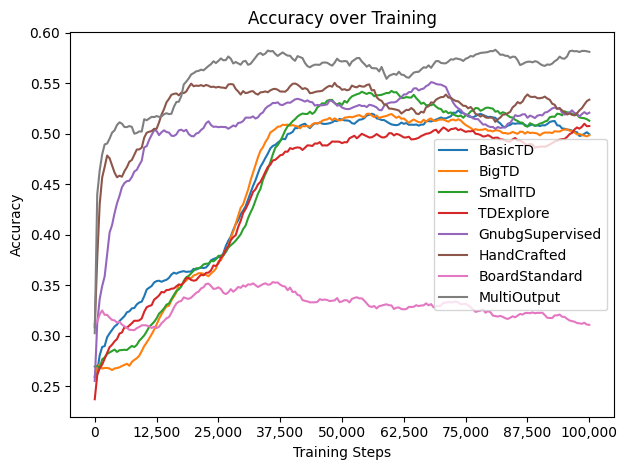

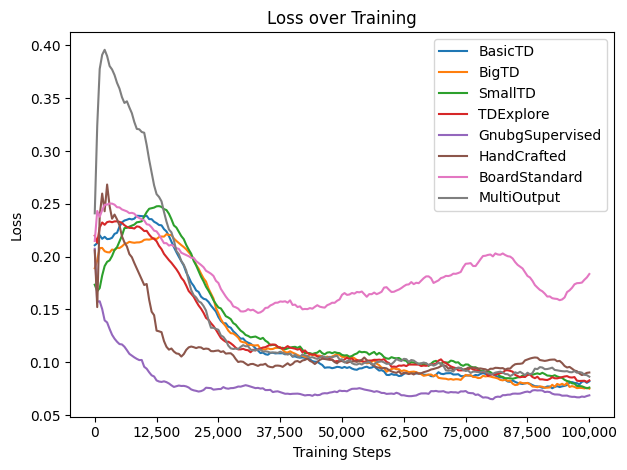

In [13]:
tournament = Tournament.load("tournament_final_10000.pkl")
for metric, label in [("history_accuracy", "Accuracy"), ("history_loss", "Loss")]:
    tournament.plot_metric(metric, label)

Looking at the change in accuracy during training, we see that BoardStandard hovers around 30-35% accuracy throughout training, suggesting that the model is finding difficulty in learning patterns throughout the whole 100,000 training games. The other 7 models converge to roughly the same accuracy of 50-55%. Interestingly, there are 3 models that reach this high accuracy much faster than the others: GnubgSupervised, HandCrafted, and MultiOutput. These are the models that have been trained using the GNUBG target throughout training. Because these models have a stable target from the beginning, they can quickly learn to imitate the moves of the GNUBG engine relatively quickly, in around 10-20k steps. The other models that use only the ground truth of win or loss at the end of each game converge much slower, reaching a competitive win rate at around 40k steps. All 7 models achieve a similar accuracy, except for MultiOutput, which has slightly higher accuracy. This may be because MultiOutput predicts the best move by incorporating information about the probability of not only a win but also a gammon and backgammon, which is similar to how the GNUBG engine predicts its best move.

We see a similar trend in the absolute loss plot, where BoardStandard fails to meaningfully learn, while the other models converge to a similar loss. We see that although GnubgSupervised and HandCrafted again achieve lower loss faster than other models, MultiOutput initially has very high loss. This may be because the model is predicting five probabilities compared to the other models that are only predicting the probability of a win. As a result, the learning problem becomes much more complex, requiring the model to see more games until it is capable of learning the win probability.


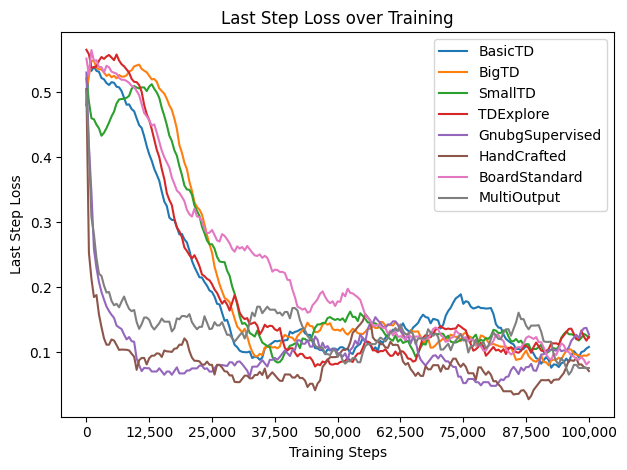

In [14]:
tournament.plot_metric("history_last_step_loss", "Last Step Loss")

Additionally, we note that when we plot the Last Step Loss, BoardStandard is performing almost identically to the other models. This suggests that this model, despite its poor performance, is learning slightly. Although it can produce accurate predictions at the end of a game when the winning player is often apparent, the board representation makes it hard for the model to accurately make predictions in more complicated situations like the middle of a game.

With training dynamics established, we turn to evaluating how the models perform against external benchmarks and each other. We use three distinct win rates to do this. First, win rate against a heuristic baseline: a simple hand-designed scoring function that rewards hitting opponent pieces and penalizes leaving blots exposed. This imitates the strategy a beginner who just learned the rules might use, and serves as a floor for what we would expect any trained model to clear.

Next, win rate against the GNUBG engine. As discussed above, GNUBG represents top-level play, so performance here tells us how closely our models approach the ceiling.

Lastly, we have each model play against all 8 others, producing a full 9x9 matrix of head-to-head win rates calculated over 10,000 games per matchup.

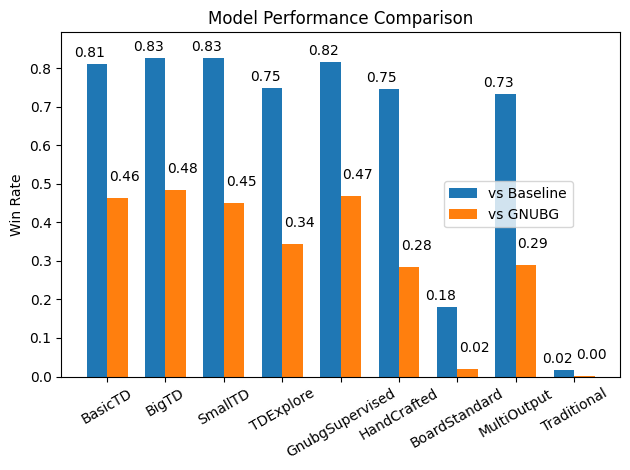

In [15]:
tournament.plot_win_rates()

We immediately see that there is a great difference between models that have successfully learned to play competitively, and models that have not been able to learn. All models except for BoardStandard and Traditional have a win rate against the heuristic baseline of over 70%, showing that these models consistently outperform a simple, beginner-level baseline. These models also have a win rate against GNUBG in the range of 28-48%, which is a decent performance against a top engine available online. The TD models (BasicTD, BigTD, SmallTD) and the GNUBG Supervised model perform especially well, approaching equal performance against GNUBG.

On the other hand, the BoardStandard and Traditional models have failed to successfully learn how to play Backgammon. Win rates against the heuristic baseline are 18% and 2% respectively, showing that these models cannot outperform a simple, untrained baseline. Both models consistently lose against GNUBG, suggesting that even with the luck involved in the game, they cannot win against a competitive opponent.

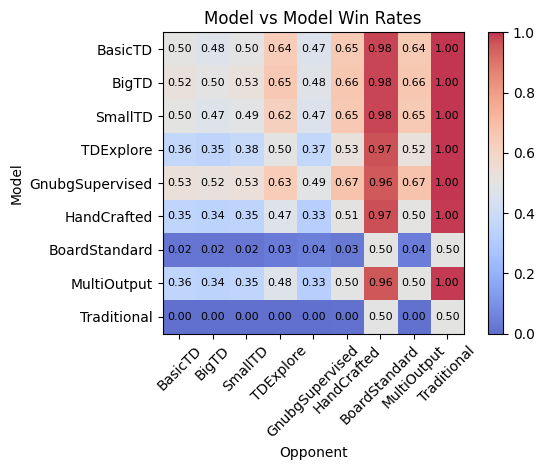

In [16]:
tournament.plot_win_rate_matrix()

Next, we compare the win rates within the trained models. Looking at the heatmap, there are three main groups of performance. The first is BasicTD, BigTD, SmallTD, and GnubgSupervised, which have a win rate of above 60% against all other models. The second group consists of TDExplore, HandCrafted, and MultiOutput, which fare slightly worse than the first group (win rate of about 35% against first group). Lastly, we have already seen that BoardStandard and Traditional perform poorly against all models, except for each other.

Importantly, we note that for matchups within each group, the win rate is between 47-53%, suggesting that models within the same group are of approximately comparable strength. This clustering suggests that there are certain feature representations and training signals that meaningfully affect model strength. Notably, Tesauro's original model (BasicTD), as well as its bigger and smaller counterparts, perform at a competitive level, showing consistency with Tesauro's 2002 findings. We see that the network size does not meaningfully impact performance, while on the other hand, using an exploratory strategy (TDExplore) makes performance drop significantly. GnubgSupervised has the highest win rate among all trained models, showing that a stable external training agent contributes to competitive results. However, HandCrafted and MultiOutput do not fare as well, suggesting that our hand-crafted feature representation loses information that the model learns using the original 198 features. The standard board feature representation seems to be almost impossible for the BoardStandard model to exploit, while using recorded gnubg games in the Traditional model led to a complete failure.

## Conclusion and Discussion

We were able to achieve in broad lines what we set out to do. We constructed a working backgammon environment, implemented and trained nine distinct model variants, and made meaningful comparisons utilizing gnubg as an external benchmark. Our gnubg-supervised model reached approximately 65% move agreement with gnubg, with a slightly worse figure for our hand-crafted feature model. The supervised model confirmed our primary hypothesis: a stable external training target converges faster and more effectively than bootstrapped self-play at this compute scale. This is consistent with Tesauro's 2002 finding that supervision quality matters more at smaller network scales. Notably, the hand-crafted feature model did not outperform the raw encoding, suggesting that the compression to 19 features loses information that the network can actually recover from raw board state when given a strong enough training signal. 

This is not to say that all efforts were successful; the traditional supervised model, trained on recorded gnubg games, underperformed significantly. We estimate this has to do with a variation in the data the model is trained on versus the data it sees when deployed. Specifically, gnubg has specific play styles that allow it to reach board states that our model might never see. This speaks to an overarching concern we addressed in our introduction: when training data is created under a fixed policy rather than the model itself, it leaves a lot of “bad” positions (and their respective best moves) as uncharted territory. 

Compared to world-class play, our results are subpar to modest, but very much in-line with the dynamics Tesauro and Berliner highlighted in their own research. Tesauro required 300,000  self-play games and roughly a month of CPU time for TD-Gammon 1.0 before results no longer improved . We trained to 50,000 games on limited personal hardware, mostly on overnight sessions. We therefor see 65% agreement as an encouraging sign given our budget, suggesting that representation quality can be a powerful tool that can help bridge computing gaps. 
If we had more time and resources to spend on this project, there are several avenues we would be interested in exploring. Longer training runs would be a great place to start, as neither our Explorer or Big TD models had converged at 50,000 games. A second idea would be to build move ranking metrics that can be called upon during evaluation: was our model’s choice one of the worst moves it could possibly pick, or second-best to gnubg’s choice?  This would allow for a more nuanced understanding of the performance gaps than merely stating a 65% agreement. Additionally, the doubling cube opens up many new dimensions to our desired outcomes, requiring our agent to recognize when the expected value of a board state justifies doubling the stakes, accepting a bet, or resigning. 



## Group Contributions


Wills took lead in the environment engineering, as he was most familiar with the project initially, and done previous work in the domain (he is also our most solid backgammon player). He oversaw the initial self-play training loop, as well legal move generation and dice handling. He also implemented basic and exploratory model variants, took responsibility for the bulk of code refactoring to keep our repo organized in src/ and scripts/ directories, and wrote up the data section of the report.

Camiel focused on model architecture, the gnubg supervision pipeline, and feature engineering. He reconstructed our supervised grubg model from eligibility traces to Adam and MSE after sigmoid saturation killed gradient flow very early on. He built the Multi model, in order to predict all five gnubg outcome probabilities, and implemented an weighted equity value to select moves. In terms of the report, he led the writing of the introduction, values statement, abstract and conclusion, and produced the slides for our in-class presentation. 

Shingo designed and implemented our heuristic baseline and class for tournament evaluation, which is used for head-to-head model comparison. He also co-led experiment design, performed the training runs for the final model lineup, and analyzed our evaluation metrics across training to draw meaningful conclusions from our results, and generated the graphs and charts utilized in our presentation. In our report he wrote up the results and approach sections.
